# Charged Black Holes in Entangled Relativity

## Arnaud Crepinge - M2 Internship

### Black Hole Phenomenology

#### Circular Orbits

In [1]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Font for plotting

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})

## 1 - Core Functions

In [2]:
# ---------- Horizons ----------

def horizons_gr(M, q):
    Q = q * M
    root = np.sqrt(M**2 - Q**2)
    return M + root, M - root


def horizons_er(M, q):
    Q = q * M
    root = np.sqrt(M**2 - (11.0 / 12.0) * Q**2)
    r_plus = M + root
    r_minus = (13.0 / 11.0) * (M - root)
    return r_plus, r_minus


# ---------- ER coordinate radius <-> areal radius ----------

def r_to_rho_er(r, M, q):
    _, r_minus = horizons_er(M, q)
    r = np.asarray(r, dtype=float)
    return r * (1.0 - r_minus / r)**(1.0 / 13.0)


def rho_to_r_er(rho, M, q, n_iterations=14):
    rho = np.asarray(rho, dtype=float)
    r_plus, r_minus = horizons_er(M, q)

    # Exterior initial guess
    r = np.maximum(rho + r_minus / 13.0, r_plus * (1.0 + 1e-10))

    for _ in range(n_iterations):
        u = 1.0 - r_minus / r
        f = r * u**(1.0 / 13.0) - rho
        fp = u**(-12.0 / 13.0) * (
            1.0 - 12.0 * r_minus / (13.0 * r)
        )
        r_new = r - f / fp
        r = np.where(
            r_new > r_minus * (1.0 + 1e-12),
            r_new,
            0.5 * (r + r_minus)
        )

    return r


# ---------- ISCO ----------

def isco_r_gr(M, q):
    Q = q * M

    # RN ISCO equation:
    # r^3 - 6 M r^2 + 9 Q^2 r - 4 Q^4/M = 0
    coefficients = [
        1.0,
        -6.0 * M,
        9.0 * Q**2,
        -4.0 * Q**4 / M
    ]

    roots = np.roots(coefficients)
    roots = roots[np.abs(roots.imag) < 1e-8].real

    r_plus, _ = horizons_gr(M, q)
    roots = roots[roots > r_plus * (1.0 + 1e-8)]

    return np.max(roots)


def isco_r_er(M, q):
    r_plus, r_minus = horizons_er(M, q)

    # Quartic marginal-stability equation for the ER metric.
    coefficients = [
        2197.0 * r_plus + 1859.0 * r_minus,

        -(
            6591.0 * r_plus**2
            + 13351.0 * r_plus * r_minus
            + 6578.0 * r_minus**2
        ),

        (
            24336.0 * r_plus**2 * r_minus
            + 25740.0 * r_plus * r_minus**2
            + 4620.0 * r_minus**3
        ),

        -(
            31668.0 * r_plus**2 * r_minus**2
            + 14388.0 * r_plus * r_minus**3
        ),

        13824.0 * r_plus**2 * r_minus**3
    ]

    roots = np.roots(coefficients)
    roots = roots[np.abs(roots.imag) < 1e-7].real
    roots = roots[roots > r_plus * (1.0 + 1e-8)]

    return np.max(roots)


def isco_rho_gr(M, q):
    return isco_r_gr(M, q)


def isco_rho_er(M, q):
    return r_to_rho_er(isco_r_er(M, q), M, q)


# ---------- Kepler laws ----------

def omega_gr(rho, M, q):
    rho = np.asarray(rho, dtype=float)
    Q = q * M

    omega_squared = M / rho**3 - Q**2 / rho**4

    if np.any(omega_squared <= 0.0):
        return np.full_like(rho, np.nan)

    return np.sqrt(omega_squared)


def omega_er(rho, M, q):
    rho = np.asarray(rho, dtype=float)
    Q = q * M

    r = rho_to_r_er(rho, M, q)
    _, r_minus = horizons_er(M, q)

    omega_squared = (
        (M / r**3 - Q**2 / r**4)
        * (1.0 - r_minus / r)**(9.0 / 13.0)
        / (1.0 - 12.0 * r_minus / (13.0 * r))
    )

    if np.any(omega_squared <= 0.0):
        return np.full_like(rho, np.nan)

    return np.sqrt(omega_squared)

## 2 - Parameters

In [3]:
SEED = 20260618

M_TRUE = 1.0
Q_TRUE_SINGLE = 0.90

N_ORBITS = 100
RHO_MAX_OVER_M = 15.0
ISCO_BUFFER = 1.01

FRACTIONAL_OMEGA_ERROR = 0.01

M_BOUNDS = (0.5, 1.5)
Q_MAX_GR = 1
Q_MAX_ER = np.sqrt(143/132)

N_REALIZATIONS = 1000

Q_TRUE_VALUES = np.array([
    0.10,
    0.30,
    0.50,
    0.70,
    0.90,
    1.0
])

rng = np.random.default_rng(SEED)

print("M_true =", M_TRUE)
print("q_true for the single example =", Q_TRUE_SINGLE)
print("number of orbits =", N_ORBITS)
print("fractional Omega error =", FRACTIONAL_OMEGA_ERROR)
print("number of realizations per charge =", N_REALIZATIONS)

M_true = 1.0
q_true for the single example = 0.9
number of orbits = 100
fractional Omega error = 0.01
number of realizations per charge = 1000


## Mock Data Generation and Fit Functions

In [4]:
def largest_isco_rho(M, q):
    return max(
        isco_rho_gr(M, q),
        isco_rho_er(M, q)
    )


def generate_er_mock_data(M_true, q_true, rng):
    rho_min = ISCO_BUFFER * largest_isco_rho(M_true, q_true)
    rho_max = RHO_MAX_OVER_M * M_true

    rho = np.sort(
        rng.uniform(rho_min, rho_max, N_ORBITS)
    )

    omega_true = omega_er(rho, M_true, q_true)
    sigma_omega = FRACTIONAL_OMEGA_ERROR * omega_true

    omega_observed = (
        omega_true
        + rng.normal(0.0, sigma_omega)
    )

    return rho, omega_true, omega_observed, sigma_omega


def initial_guess(rho, omega_observed):
    # Newtonian estimate M ~ Omega^2 rho^3
    M_guess = np.median(
        omega_observed**2 * rho**3
    )
    M_guess = np.clip(
        M_guess,
        M_BOUNDS[0] + 1e-4,
        M_BOUNDS[1] - 1e-4
    )

    return np.array([M_guess, 0.5])


def fit_model(model, rho, omega_observed, sigma_omega):
    p0 = initial_guess(rho, omega_observed)

    Qmax = Q_MAX_GR if model == omega_gr else Q_MAX_ER

    parameters, covariance = curve_fit(
        model,
        rho,
        omega_observed,
        p0=p0,
        sigma=sigma_omega,
        absolute_sigma=True,
        bounds=(
            [M_BOUNDS[0], 0],
            [M_BOUNDS[1], Qmax]
        ),
        maxfev=20000
    )

    uncertainties = np.sqrt(
        np.maximum(np.diag(covariance), 0.0)
    )

    prediction = model(rho, *parameters)

    chi_squared = np.sum(
        ((omega_observed - prediction) / sigma_omega)**2
    )

    return parameters, covariance, uncertainties, chi_squared


def derived_Q_and_error(parameters, covariance):
    M, q = parameters
    Q = M * q

    gradient = np.array([q, M])
    variance_Q = gradient @ covariance @ gradient
    sigma_Q = np.sqrt(max(variance_Q, 0.0))

    return Q, sigma_Q


def fit_both_models(rho, omega_observed, sigma_omega):
    er_result = fit_model(
        omega_er,
        rho,
        omega_observed,
        sigma_omega
    )

    gr_result = fit_model(
        omega_gr,
        rho,
        omega_observed,
        sigma_omega
    )

    return er_result, gr_result

## 4 - One realization

In [5]:
rho_single, omega_true_single, omega_obs_single, sigma_single = (
    generate_er_mock_data(
        M_TRUE,
        Q_TRUE_SINGLE,
        rng
    )
)

er_single, gr_single = fit_both_models(
    rho_single,
    omega_obs_single,
    sigma_single
)

def print_single_fit(name, result):
    parameters, covariance, uncertainties, chi_squared = result
    M_fit, q_fit = parameters
    sigma_M, sigma_q = uncertainties
    Q_fit, sigma_Q = derived_Q_and_error(
        parameters,
        covariance
    )

    print(name)
    print(f"  M = {M_fit:.6f} +/- {sigma_M:.6f}")
    print(f"  q = Q/M = {q_fit:.6f} +/- {sigma_q:.6f}")
    print(f"  Q = {Q_fit:.6f} +/- {sigma_Q:.6f}")
    print(f"  chi2 = {chi_squared:.3f}")
    print(f"  reduced chi2 = {chi_squared/(N_ORBITS - 2):.3f}")
    print()


print("True values")
print(f"  M_true = {M_TRUE}")
print(f"  q_true = {Q_TRUE_SINGLE}")
print(f"  Q_true = {M_TRUE * Q_TRUE_SINGLE}")
print()

print_single_fit("ER fit", er_single)
print_single_fit("GR fit", gr_single)

True values
  M_true = 1.0
  q_true = 0.9
  Q_true = 0.9

ER fit
  M = 0.998708 +/- 0.005209
  q = Q/M = 0.906842 +/- 0.018114
  Q = 0.905670 +/- 0.022448
  chi2 = 76.163
  reduced chi2 = 0.777

GR fit
  M = 0.998219 +/- 0.005160
  q = Q/M = 0.903003 +/- 0.017833
  Q = 0.901395 +/- 0.022092
  chi2 = 76.238
  reduced chi2 = 0.778



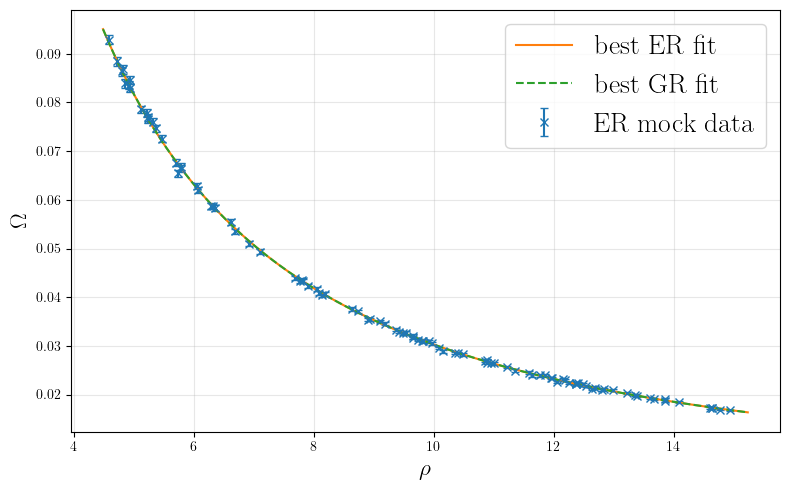

In [6]:
rho_plot = np.linspace(
    0.98 * rho_single.min(),
    1.02 * rho_single.max(),
    500
)

plt.figure(figsize=(8, 5))
plt.errorbar(
    rho_single,
    omega_obs_single,
    yerr=sigma_single,
    fmt="x",
    capsize=3,
    label="ER mock data"
)
plt.plot(
    rho_plot,
    omega_er(
        rho_plot,
        er_single[0][0],
        er_single[0][1]
    ),
    label="best ER fit"
)
plt.plot(
    rho_plot,
    omega_gr(
        rho_plot,
        gr_single[0][0],
        gr_single[0][1]
    ),
    linestyle="--",
    label="best GR fit"
)
plt.xlabel(r"$\rho$", fontsize=17)
plt.ylabel(r"$\Omega$", fontsize=17)

plt.grid(alpha=0.3)
plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig("images/MockData.png", dpi=150, bbox_inches='tight')

## 5 - Multiple Realizations

In [7]:
def run_realizations(M_true, q_true, n_realizations, rng):
    er_parameters = []
    gr_parameters = []

    er_uncertainties = []
    gr_uncertainties = []

    er_chi_squared = []
    gr_chi_squared = []

    failures = 0

    for _ in range(n_realizations):
        rho, _, omega_observed, sigma_omega = (
            generate_er_mock_data(
                M_true,
                q_true,
                rng
            )
        )

        try:
            er_result, gr_result = fit_both_models(
                rho,
                omega_observed,
                sigma_omega
            )

            er_parameters.append(er_result[0])
            gr_parameters.append(gr_result[0])

            er_uncertainties.append(er_result[2])
            gr_uncertainties.append(gr_result[2])

            er_chi_squared.append(er_result[3])
            gr_chi_squared.append(gr_result[3])

        except (RuntimeError, ValueError, FloatingPointError):
            failures += 1

    return {
        "er_parameters": np.asarray(er_parameters),
        "gr_parameters": np.asarray(gr_parameters),
        "er_uncertainties": np.asarray(er_uncertainties),
        "gr_uncertainties": np.asarray(gr_uncertainties),
        "er_chi_squared": np.asarray(er_chi_squared),
        "gr_chi_squared": np.asarray(gr_chi_squared),
        "failures": failures
    }


single_ensemble = run_realizations(
    M_TRUE,
    Q_TRUE_SINGLE,
    N_REALIZATIONS,
    rng
)

print("Successful realizations =",
      len(single_ensemble["er_parameters"]))
print("Failures =", single_ensemble["failures"])

Successful realizations = 1000
Failures = 0


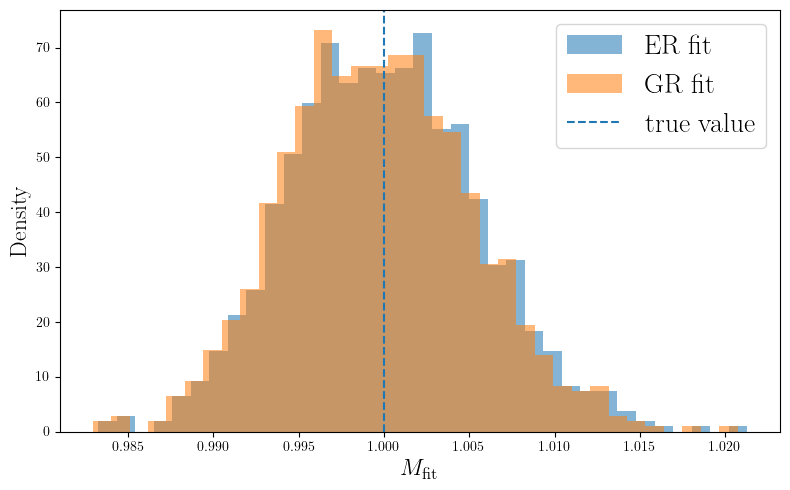

In [8]:
er_M = single_ensemble["er_parameters"][:, 0]
er_q = single_ensemble["er_parameters"][:, 1]

gr_M = single_ensemble["gr_parameters"][:, 0]
gr_q = single_ensemble["gr_parameters"][:, 1]

plt.figure(figsize=(8, 5))
plt.hist(
    er_M,
    bins=35,
    alpha=0.55,
    label="ER fit",
    density=True
)
plt.hist(
    gr_M,
    bins=35,
    alpha=0.55,
    label="GR fit",
    density=True
)
plt.axvline(
    M_TRUE,
    linestyle="--",
    linewidth=1.5,
    label="true value"
)
plt.xlabel(r"$M_{\rm fit}$", fontsize=17)
plt.ylabel("Density", fontsize=17)

plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig("images/MassDistrib.png", dpi=150, bbox_inches='tight')

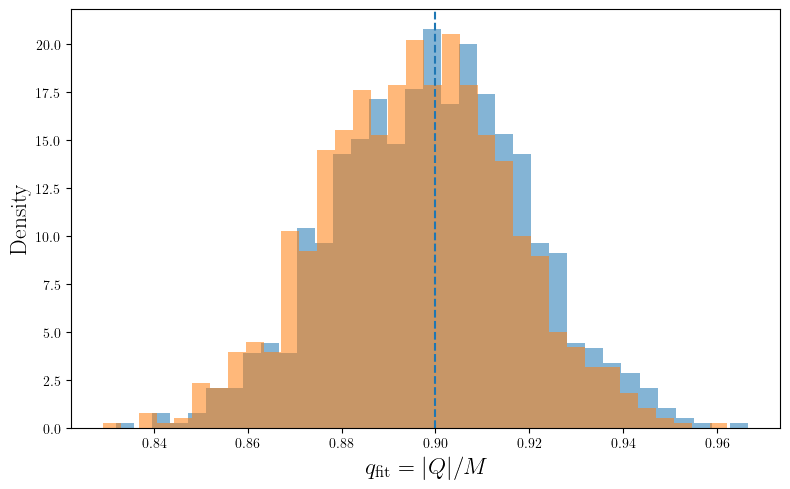

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(
    er_q,
    bins=35,
    alpha=0.55,
    label="ER fit",
    density=True
)
plt.hist(
    gr_q,
    bins=35,
    alpha=0.55,
    label="GR fit",
    density=True
)
plt.axvline(
    Q_TRUE_SINGLE,
    linestyle="--",
    linewidth=1.5,
    label="true value"
)
plt.xlabel(r"$q_{\rm fit}=|Q|/M$", fontsize=17)
plt.ylabel("Density", fontsize=17)

#plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig("images/ChargeDistrib.png", dpi=150, bbox_inches='tight')

In [10]:
def print_ensemble_summary(name, parameters, uncertainties, chi_squared):
    mean_parameters = np.mean(parameters, axis=0)
    scatter_parameters = np.std(parameters, axis=0, ddof=1)
    mean_uncertainties = np.mean(uncertainties, axis=0)

    print(name)
    print(
        "  mean fitted M = "
        f"{mean_parameters[0]:.6f}"
    )
    print(
        "  realization scatter in M = "
        f"{scatter_parameters[0]:.6f}"
    )
    print(
        "  mean reported sigma_M = "
        f"{mean_uncertainties[0]:.6f}"
    )
    print(
        "  mean fitted q = "
        f"{mean_parameters[1]:.6f}"
    )
    print(
        "  realization scatter in q = "
        f"{scatter_parameters[1]:.6f}"
    )
    print(
        "  mean reported sigma_q = "
        f"{mean_uncertainties[1]:.6f}"
    )
    print(
        "  mean chi2 = "
        f"{np.mean(chi_squared):.3f}"
    )
    print()


print_ensemble_summary(
    "ER ensemble",
    single_ensemble["er_parameters"],
    single_ensemble["er_uncertainties"],
    single_ensemble["er_chi_squared"]
)

print_ensemble_summary(
    "GR ensemble",
    single_ensemble["gr_parameters"],
    single_ensemble["gr_uncertainties"],
    single_ensemble["gr_chi_squared"]
)

print("Expected mean chi2 for the correct model =",
      N_ORBITS - 2)

ER ensemble
  mean fitted M = 1.000077
  realization scatter in M = 0.005526
  mean reported sigma_M = 0.005545
  mean fitted q = 0.899387
  realization scatter in q = 0.020394
  mean reported sigma_q = 0.020530
  mean chi2 = 98.130

GR ensemble
  mean fitted M = 0.999652
  realization scatter in M = 0.005477
  mean reported sigma_M = 0.005495
  mean fitted q = 0.895862
  realization scatter in q = 0.020096
  mean reported sigma_q = 0.020229
  mean chi2 = 98.129

Expected mean chi2 for the correct model = 98


## 6 - Different True Charge-to-Mass Ratio

In [11]:
charge_scan = {}

for q_true in Q_TRUE_VALUES:
    print(f"Running q_true = {q_true:.2f}")

    charge_scan[q_true] = run_realizations(
        M_TRUE,
        q_true,
        N_REALIZATIONS,
        rng
    )

print("Charge scan complete.")

Running q_true = 0.10
Running q_true = 0.30
Running q_true = 0.50
Running q_true = 0.70
Running q_true = 0.90
Running q_true = 1.00
Charge scan complete.


In [12]:
print(
    f"{'q_true':>7s} "
    f"{'model':>6s} "
    f"{'<M_fit>':>10s} "
    f"{'std(M)':>10s} "
    f"{'<q_fit>':>10s} "
    f"{'std(q)':>10s} "
    f"{'<chi2>':>10s}"
)
print("-" * 72)

for q_true in Q_TRUE_VALUES:
    result = charge_scan[q_true]

    for model_name, parameter_key, chi_key in [
        ("ER", "er_parameters", "er_chi_squared"),
        ("GR", "gr_parameters", "gr_chi_squared")
    ]:
        parameters = result[parameter_key]
        chi_values = result[chi_key]

        print(
            f"{q_true:7.2f} "
            f"{model_name:>6s} "
            f"{np.mean(parameters[:, 0]):10.6f} "
            f"{np.std(parameters[:, 0], ddof=1):10.6f} "
            f"{np.mean(parameters[:, 1]):10.6f} "
            f"{np.std(parameters[:, 1], ddof=1):10.6f} "
            f"{np.mean(chi_values):10.3f}"
        )

 q_true  model    <M_fit>     std(M)    <q_fit>     std(q)     <chi2>
------------------------------------------------------------------------
   0.10     ER   1.002690   0.005235   0.130927   0.135964     98.594
   0.10     GR   1.002689   0.005233   0.130889   0.135911     98.594
   0.30     ER   1.000286   0.007078   0.272301   0.134701     98.449
   0.30     GR   1.000281   0.007072   0.272182   0.134605     98.449
   0.50     ER   1.000418   0.007026   0.498463   0.064609     97.398
   0.50     GR   1.000390   0.007013   0.497978   0.064433     97.398
   0.70     ER   0.999952   0.006493   0.698161   0.036784     97.752
   0.70     GR   0.999836   0.006467   0.696764   0.036550     97.752
   0.90     ER   1.000032   0.005432   0.899553   0.020461     98.341
   0.90     GR   0.999608   0.005383   0.896034   0.020165     98.343
   1.00     ER   1.000201   0.004685   1.000356   0.013888     97.845
   1.00     GR   0.998385   0.003691   0.991570   0.009935     98.070


## 7 - Bias for varying charge

In [13]:
er_mass_bias_mean = []
gr_mass_bias_mean = []

er_mass_bias_std = []
gr_mass_bias_std = []

er_q_bias_mean = []
gr_q_bias_mean = []

er_q_bias_std = []
gr_q_bias_std = []

for q_true in Q_TRUE_VALUES:
    result = charge_scan[q_true]

    er_parameters = result["er_parameters"]
    gr_parameters = result["gr_parameters"]

    er_mass_bias = er_parameters[:, 0] / M_TRUE - 1.0
    gr_mass_bias = gr_parameters[:, 0] / M_TRUE - 1.0

    er_charge_bias = er_parameters[:, 1] - q_true
    gr_charge_bias = gr_parameters[:, 1] - q_true

    er_mass_bias_mean.append(np.mean(er_mass_bias))
    gr_mass_bias_mean.append(np.mean(gr_mass_bias))

    er_mass_bias_std.append(np.std(er_mass_bias, ddof=1))
    gr_mass_bias_std.append(np.std(gr_mass_bias, ddof=1))

    er_q_bias_mean.append(np.mean(er_charge_bias))
    gr_q_bias_mean.append(np.mean(gr_charge_bias))

    er_q_bias_std.append(np.std(er_charge_bias, ddof=1))
    gr_q_bias_std.append(np.std(gr_charge_bias, ddof=1))

er_mass_bias_mean = np.asarray(er_mass_bias_mean)
gr_mass_bias_mean = np.asarray(gr_mass_bias_mean)

er_mass_bias_std = np.asarray(er_mass_bias_std)
gr_mass_bias_std = np.asarray(gr_mass_bias_std)

er_q_bias_mean = np.asarray(er_q_bias_mean)
gr_q_bias_mean = np.asarray(gr_q_bias_mean)

er_q_bias_std = np.asarray(er_q_bias_std)
gr_q_bias_std = np.asarray(gr_q_bias_std)

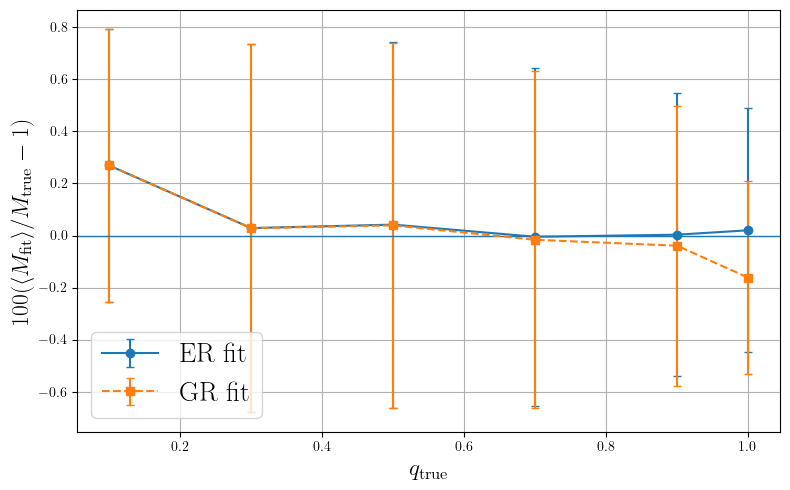

In [14]:
plt.figure(figsize=(8, 5))
plt.errorbar(
    Q_TRUE_VALUES,
    100.0 * er_mass_bias_mean,
    yerr=100.0 * er_mass_bias_std,
    fmt="o-",
    capsize=3,
    label="ER fit"
)
plt.errorbar(
    Q_TRUE_VALUES,
    100.0 * gr_mass_bias_mean,
    yerr=100.0 * gr_mass_bias_std,
    fmt="s--",
    capsize=3,
    label="GR fit"
)
plt.axhline(0.0, linewidth=1)
plt.xlabel(r"$q_{\rm true}$", fontsize=17)
plt.ylabel(r"$100(\langle M_{\rm fit}\rangle/M_{\rm true}-1)$", fontsize=17)

plt.grid()
plt.legend(fontsize=20)
plt.tight_layout()

plt.savefig("images/MassBias.png", dpi=150, bbox_inches='tight')

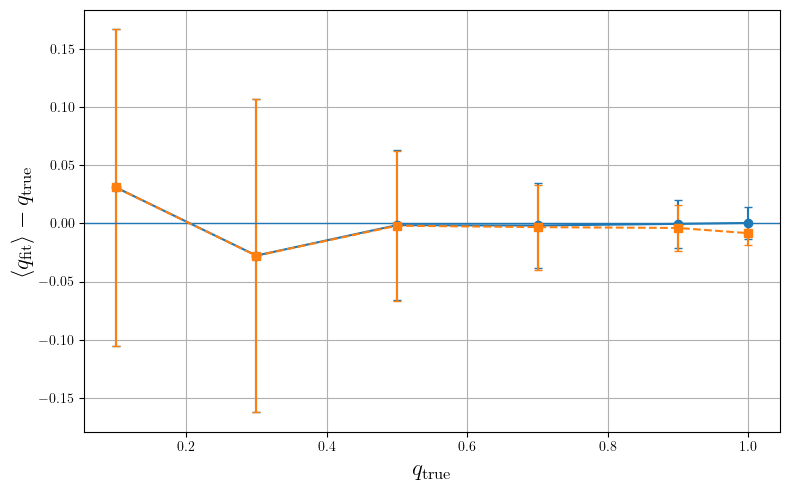

In [15]:
plt.figure(figsize=(8, 5))
plt.errorbar(
    Q_TRUE_VALUES,
    er_q_bias_mean,
    yerr=er_q_bias_std,
    fmt="o-",
    capsize=3,
    label="ER fit"
)
plt.errorbar(
    Q_TRUE_VALUES,
    gr_q_bias_mean,
    yerr=gr_q_bias_std,
    fmt="s--",
    capsize=3,
    label="GR fit"
)
plt.axhline(0.0, linewidth=1)
plt.xlabel(r"$q_{\rm true}$", fontsize=17)
plt.ylabel(r"$\langle q_{\rm fit}\rangle-q_{\rm true}$", fontsize=17)

plt.grid()
plt.tight_layout()

plt.savefig("images/ChargeBias.png", dpi=150, bbox_inches='tight')

## 8 - Noiseless GR Bias

In [16]:
noiseless_er_parameters = []
noiseless_gr_parameters = []

for q_true in Q_TRUE_VALUES:
    rho_min = (
        ISCO_BUFFER
        * largest_isco_rho(M_TRUE, q_true)
    )

    rho = np.linspace(
        rho_min,
        RHO_MAX_OVER_M * M_TRUE,
        80
    )

    omega_exact = omega_er(
        rho,
        M_TRUE,
        q_true
    )

    # The overall normalization of sigma does not change
    # the best-fit point for this noiseless calculation.
    sigma = FRACTIONAL_OMEGA_ERROR * omega_exact

    er_fit = fit_model(
        omega_er,
        rho,
        omega_exact,
        sigma
    )

    gr_fit = fit_model(
        omega_gr,
        rho,
        omega_exact,
        sigma
    )

    noiseless_er_parameters.append(er_fit[0])
    noiseless_gr_parameters.append(gr_fit[0])

noiseless_er_parameters = np.asarray(
    noiseless_er_parameters
)
noiseless_gr_parameters = np.asarray(
    noiseless_gr_parameters
)

print(
    f"{'q_true':>7s} "
    f"{'M_GR':>12s} "
    f"{'q_GR':>12s} "
    f"{'mass bias (%)':>15s} "
    f"{'q bias':>12s}"
)
print("-" * 66)

for i, q_true in enumerate(Q_TRUE_VALUES):
    M_gr, q_gr = noiseless_gr_parameters[i]

    print(
        f"{q_true:7.2f} "
        f"{M_gr:12.8f} "
        f"{q_gr:12.8f} "
        f"{100.0*(M_gr/M_TRUE - 1.0):15.6f} "
        f"{q_gr - q_true:12.8f}"
    )

 q_true         M_GR         q_GR   mass bias (%)       q bias
------------------------------------------------------------------
   0.10   0.99999996   0.09999654       -0.000004  -0.00000346
   0.30   0.99999698   0.29990433       -0.000302  -0.00009567
   0.50   0.99997436   0.49953364       -0.002564  -0.00046636
   0.70   0.99988360   0.69859522       -0.011640  -0.00140478
   0.90   0.99956973   0.89644100       -0.043027  -0.00355900
   1.00   0.99914031   0.99423919       -0.085969  -0.00576081
